In [1]:
import pandas as pd
import numpy as np
import tidyfinance as tf

In [2]:
prices = tf.download_data(
  domain="stock_prices", 
  symbols="AAPL",
  start_date="2000-01-01", 
  end_date="2023-12-31"
)
prices.head().round(3)

,date,symbol,volume,open,low,high,close,adjusted_close
0,2000-01-03,AAPL,535796800,0.936,0.908,1.004,0.999,0.840
1,2000-01-04,AAPL,512377600,0.967,0.903,0.988,0.915,0.769
2,2000-01-05,AAPL,778321600,0.926,0.920,0.987,0.929,0.781
3,2000-01-06,AAPL,767972800,0.948,0.848,0.955,0.848,0.713
4,2000-01-07,AAPL,460734400,0.862,0.853,0.902,0.888,0.747


In [3]:
from plotnine import *

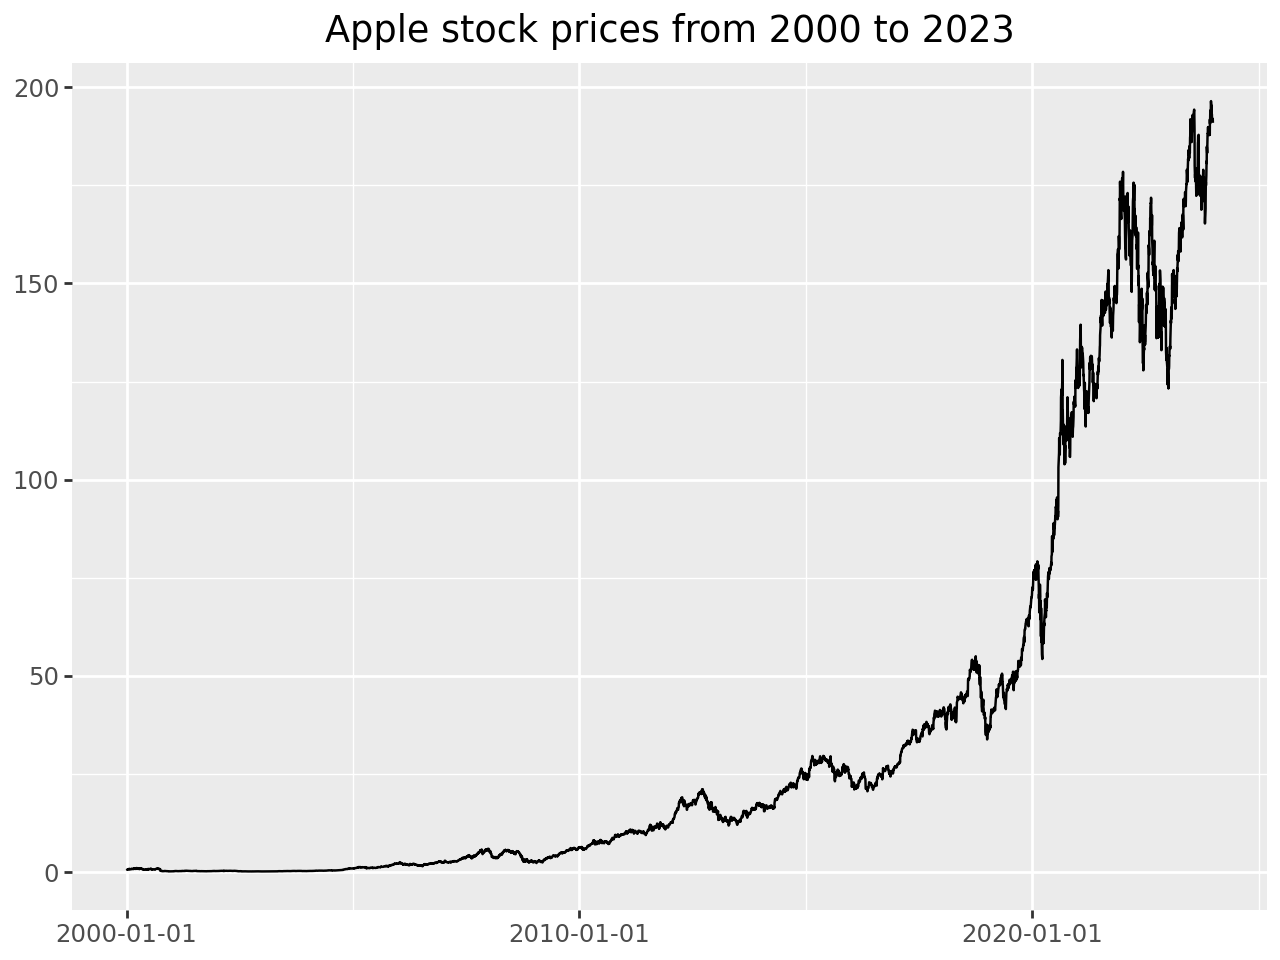

In [4]:
apple_prices_figure = (
  ggplot(prices, aes(y="adjusted_close", x="date"))
  + geom_line()
  + labs(x="", y="", title="Apple stock prices from 2000 to 2023")
)
apple_prices_figure.show()

In [5]:
returns = (prices
  .sort_values("date")
  .assign(ret=lambda x: x["adjusted_close"].pct_change())
  .get(["symbol", "date", "ret"])
)
returns

,symbol,date,ret
0,AAPL,2000-01-03,NaN
1,AAPL,2000-01-04,-0.084310
2,AAPL,2000-01-05,0.014633
3,AAPL,2000-01-06,-0.086538
4,AAPL,2000-01-07,0.047369
...,...,...,...
6032,AAPL,2023-12-22,-0.005548
6033,AAPL,2023-12-26,-0.002841
6034,AAPL,2023-12-27,0.000518
6035,AAPL,2023-12-28,0.002226


In [6]:
returns = returns.dropna() 

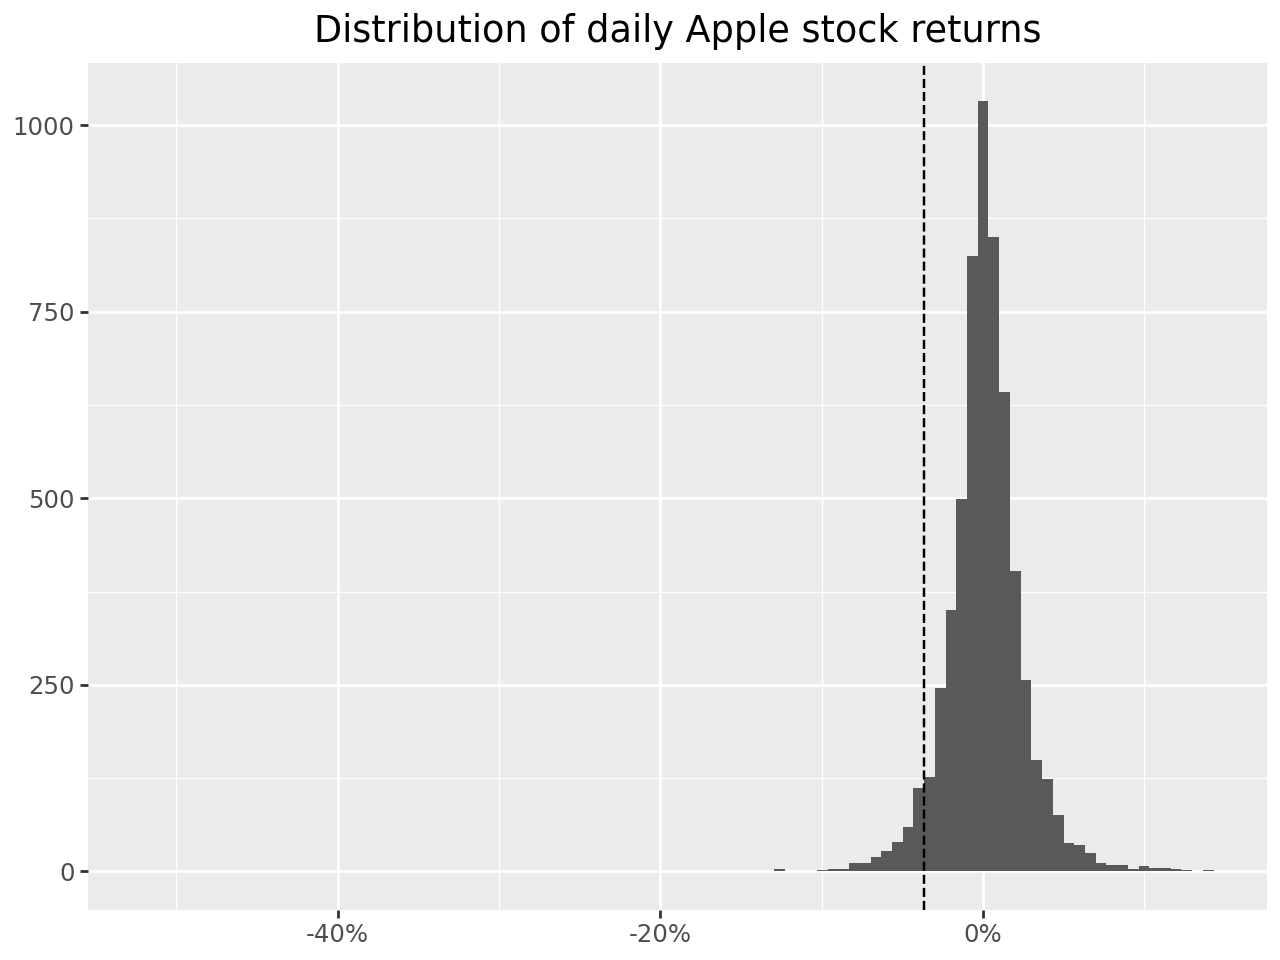

In [7]:
from mizani.formatters import percent_format

quantile_05 = returns["ret"].quantile(0.05)

apple_returns_figure = (
  ggplot(returns, aes(x="ret"))
  + geom_histogram(bins=100)
  + geom_vline(aes(xintercept=quantile_05), linetype="dashed")
  + labs(x="", y="", title="Distribution of daily Apple stock returns")
  + scale_x_continuous(labels=percent_format())
)
apple_returns_figure.show()